# Deepfake Video Detection with EfficientNet-B0 + LSTM
## Multi-Dataset Training for Better Generalization

This notebook implements a robust deepfake detection system using:
- **EfficientNet-B0** for spatial feature extraction
- **LSTM** for temporal modeling
- **Multi-dataset training** (CelebDF-v2, FaceForensics++, DFDC)
- **Advanced augmentation** for better generalization
- **GPU-optimized** for RTX 4060

## 1. Setup and Installation

In [2]:
# Install required packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python
!pip install facenet-pytorch  # For MTCNN face detection
!pip install albumentations
!pip install timm  # For pretrained EfficientNet
!pip install scikit-learn
!pip install matplotlib seaborn
!pip install tqdm
!pip install tensorboard

Looking in indexes: https://download.pytorch.org/whl/cu118


In [3]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
!nvidia-smi

Wed Mar  4 15:50:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   57C    P0             33W /   80W |     694MiB /   8188MiB |     43%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os
import cv2
import json
import random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms

# Pretrained models
import timm

# Face detection
from facenet_pytorch import MTCNN

# Augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version: 12.8
Available GPU Memory: 8.19 GB


In [6]:
class DatasetLoader:

    def __init__(self, config):
        self.config = config
        self.videos = []
        self.labels = []

    # ==============================
    # FaceForensics++
    # ==============================
    def load_ffpp(self):
        root = self.config.FFPP_PATH

        real_path = os.path.join(root, "original")
        fake_types = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

        if os.path.exists(real_path):
            for v in os.listdir(real_path):
                full = os.path.join(real_path, v)
                if os.path.isfile(full):
                    self.videos.append(full)
                    self.labels.append(0)

        for fake in fake_types:
            fake_path = os.path.join(root, fake)
            if not os.path.exists(fake_path):
                continue

            for v in os.listdir(fake_path):
                full = os.path.join(fake_path, v)
                if os.path.isfile(full):
                    self.videos.append(full)
                    self.labels.append(1)

    # ==============================
    # DFDC (Metadata Based)
    # ==============================
    def load_dfdc(self):
        root = self.config.DFDC_PATH
        parts = [d for d in os.listdir(root) if "dfdc_train_part" in d]

        for part in parts:
            part_path = os.path.join(root, part)
            metadata_path = os.path.join(part_path, "metadata.json")

            if not os.path.exists(metadata_path):
                continue

            with open(metadata_path, "r") as f:
                metadata = json.load(f)

            for vid, info in metadata.items():
                full = os.path.join(part_path, vid)

                if not os.path.exists(full):
                    continue

                label = 1 if info["label"] == "FAKE" else 0
                self.videos.append(full)
                self.labels.append(label)

    # ==============================
    # Celeb-DF v2
    # ==============================
    def load_celeb(self):
        root = self.config.CELEB_PATH

        real = os.path.join(root, "Celeb-real")
        fake = os.path.join(root, "Celeb-synthesis")

        if os.path.exists(real):
            for v in os.listdir(real):
                full = os.path.join(real, v)
                if os.path.isfile(full):
                    self.videos.append(full)
                    self.labels.append(0)

        if os.path.exists(fake):
            for v in os.listdir(fake):
                full = os.path.join(fake, v)
                if os.path.isfile(full):
                    self.videos.append(full)
                    self.labels.append(1)

    # ==============================
    # DeeperForensics
    # ==============================
    def load_deeper(self):
        root = self.config.DEEPER_PATH

        real = os.path.join(root, "real")
        fake = os.path.join(root, "fake")

        if os.path.exists(real):
            for v in os.listdir(real):
                full = os.path.join(real, v)
                if os.path.isfile(full):
                    self.videos.append(full)
                    self.labels.append(0)

        if os.path.exists(fake):
            for v in os.listdir(fake):
                full = os.path.join(fake, v)
                if os.path.isfile(full):
                    self.videos.append(full)
                    self.labels.append(1)

    # ==============================
    # Load All Selected Datasets
    # ==============================
    def load_all(self):

        if self.config.USE_FFPP:
            print("Loading FaceForensics++...")
            self.load_ffpp()

        if self.config.USE_DFDC:
            print("Loading DFDC...")
            self.load_dfdc()

        if self.config.USE_CELEB:
            print("Loading Celeb-DF...")
            self.load_celeb()

        if self.config.USE_DEEPER:
            print("Loading DeeperForensics...")
            self.load_deeper()

        print("Before balancing:", Counter(self.labels))

        if self.config.BALANCE_DATA:
            self.balance_dataset()

        print("After balancing:", Counter(self.labels))

        return self.videos, self.labels

    # ==============================
    # Balance Dataset
    # ==============================
    def balance_dataset(self):
        real = [(v,l) for v,l in zip(self.videos, self.labels) if l == 0]
        fake = [(v,l) for v,l in zip(self.videos, self.labels) if l == 1]

        min_len = min(len(real), len(fake))

        real = random.sample(real, min_len)
        fake = random.sample(fake, min_len)

        combined = real + fake
        random.shuffle(combined)

        self.videos, self.labels = map(list, zip(*combined))

## 2. Configuration

In [7]:
class Config:
    # Paths - UPDATE THESE WITH YOUR DATASET PATHS
    FF_PLUS_PATH = "/home/andy/Downloads/DF Training BE Proj/datasets/FaceForensics++/faceforeinsics_df/FaceForensics++_C23"
    DFDC_PATH = "/home/andy/Downloads/DF Training BE Proj/datasets/DFDC/dfdc_train_part_00"
    CELEB_DF_PATH = "/home/andy/Downloads/DF Training BE Proj/datasets/Celeb-DF-v2/celeb_df"
    DEEPER_PATH = "/home/andy/Downloads/DF Training BE Proj/datasets/DeeperForensics"
    
    # Output paths
    OUTPUT_DIR = './outputs'
    MODEL_SAVE_DIR = './models'
    LOGS_DIR = './logs'
    
    # Video processing
    SEQUENCE_LENGTH = 15  # Number of frames per video #Changed from 20 to 15
    FRAME_SIZE = 224  # EfficientNet input size
    FPS_SAMPLE = 1  # Sample 1 frame per second
    
    # Model architecture
    BACKBONE = 'efficientnet_b0'  # Can use b1, b2 for better accuracy (more GPU memory)
    LSTM_HIDDEN_SIZE = 256
    LSTM_LAYERS = 2
    LSTM_DROPOUT = 0.3
    FC_DROPOUT = 0.5
    
    # Training
    BATCH_SIZE = 4  # Adjust based on GPU memory (4060 can handle 8-16) #Changed from 8 to 4
    NUM_EPOCHS = 30
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    GRADIENT_CLIP = 1.0
    
    # Learning rate schedule
    WARMUP_EPOCHS = 3
    LR_SCHEDULER = 'cosine'  # 'cosine' or 'step'
    
    # Mixed precision training (faster on RTX 4060)
    USE_AMP = True
    
    # Data augmentation probability
    AUG_PROB = 0.5
    
    # Early stopping
    PATIENCE = 7
    
    # Multi-GPU (if available)
    NUM_WORKERS = 4
    PIN_MEMORY = True

# Create directories
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(Config.LOGS_DIR, exist_ok=True)

## 3. Face Detection and Video Processing

In [8]:
class FaceExtractor:
    """Extracts faces from video frames using MTCNN"""
    
    def __init__(self, device='cuda'):
        self.device = device
        self.detector = MTCNN(
            image_size=Config.FRAME_SIZE,
            margin=20,
            device=device,
            post_process=False,
            select_largest=True,  # Select the largest face
            keep_all=False
        )
    
    def extract_face(self, frame):
        """Extract face from a single frame"""
        try:
            # MTCNN expects RGB
            if len(frame.shape) == 2:
                frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
            elif frame.shape[2] == 4:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGRA2RGB)
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Detect and extract face
            face = self.detector(frame)
            
            if face is not None:
                return face.cpu().numpy().transpose(1, 2, 0)  # CHW to HWC
            else:
                # If no face detected, resize entire frame
                return cv2.resize(frame, (Config.FRAME_SIZE, Config.FRAME_SIZE))
        except Exception as e:
            # Fallback: resize entire frame
            if len(frame.shape) == 3:
                if frame.shape[2] == 3:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            return cv2.resize(frame, (Config.FRAME_SIZE, Config.FRAME_SIZE))


def extract_frames_from_video(video_path, num_frames=Config.SEQUENCE_LENGTH, face_extractor=None):
    """Extract uniformly sampled frames from video"""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < num_frames:
        # If video has fewer frames, we'll repeat the last frame
        frame_indices = list(range(total_frames))
    else:
        # Uniform sampling
        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        
        if ret:
            if face_extractor:
                face = face_extractor.extract_face(frame)
                frames.append(face)
            else:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_resized = cv2.resize(frame_rgb, (Config.FRAME_SIZE, Config.FRAME_SIZE))
                frames.append(frame_resized)
    
    cap.release()
    
    # Pad with last frame if needed
    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else np.zeros((Config.FRAME_SIZE, Config.FRAME_SIZE, 3)))
    
    return np.array(frames[:num_frames])

## 4. Advanced Augmentation Pipeline

In [9]:
def get_training_augmentation():
    """Advanced augmentation pipeline for better generalization"""
    return A.Compose([
        # Geometric transforms
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.3),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.3),
        
        # Color/lighting augmentations (important for cross-dataset generalization)
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=1),
            A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=1),
        ], p=0.5),
        
        # Blur/noise (simulates different video qualities)
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1),
            A.MotionBlur(blur_limit=5, p=1),
            A.GaussNoise(var_limit=(10.0, 30.0), p=1),
        ], p=0.3),
        
        # Compression artifacts (common in real-world videos)
        A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),
        
        # Pixel-level transforms
        A.OneOf([
            A.CLAHE(clip_limit=2, p=1),
            A.Sharpen(p=1),
            A.Equalize(p=1),
        ], p=0.2),
        
        # Normalization (ImageNet statistics for EfficientNet)
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ])


def get_validation_augmentation():
    """Simple augmentation for validation/test"""
    return A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ])

## 5. Dataset Class

In [10]:
class DeepfakeDataset(Dataset):
    """Multi-dataset deepfake detection dataset"""
    
    def __init__(self, video_paths, labels, transform=None, face_extractor=None, use_cache=False):
        """
        Args:
            video_paths: List of video file paths
            labels: List of labels (0=real, 1=fake)
            transform: Albumentations transform
            face_extractor: FaceExtractor instance
            use_cache: Cache extracted frames (requires lots of RAM)
        """
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform
        self.face_extractor = face_extractor
        self.use_cache = use_cache
        self.cache = {} if use_cache else None
        
    def __len__(self):
        return len(self.video_paths)
    
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        
        # Check cache first
        if self.use_cache and video_path in self.cache:
            frames = self.cache[video_path]
        else:
            # Extract frames
            frames = extract_frames_from_video(
                video_path, 
                num_frames=Config.SEQUENCE_LENGTH,
                face_extractor=self.face_extractor
            )
            
            if self.use_cache:
                self.cache[video_path] = frames
        
        # Apply augmentation to each frame
        if self.transform:
            augmented_frames = []
            for frame in frames:
                # Ensure frame is uint8
                if frame.dtype != np.uint8:
                    frame = (frame * 255).astype(np.uint8) if frame.max() <= 1.0 else frame.astype(np.uint8)
                
                augmented = self.transform(image=frame)
                augmented_frames.append(augmented['image'])
            
            frames_tensor = torch.stack(augmented_frames)  # Shape: [T, C, H, W]
        else:
            # Convert to tensor without augmentation
            frames = frames.astype(np.float32) / 255.0
            frames_tensor = torch.from_numpy(frames).permute(0, 3, 1, 2)  # [T, H, W, C] -> [T, C, H, W]
        
        return frames_tensor, torch.tensor(label, dtype=torch.float32)


def prepare_dataset_splits(dataset_configs, test_size=0.2, val_size=0.1):
    """
    Prepare train/val/test splits from multiple datasets
    
    Args:
        dataset_configs: List of dicts with 'name', 'path', 'real_folder', 'fake_folder'
        test_size: Proportion for test set
        val_size: Proportion for validation set (from remaining after test)
    
    Returns:
        train_paths, train_labels, val_paths, val_labels, test_paths, test_labels
    """
    all_video_paths = []
    all_labels = []
    
    for config in dataset_configs:
        dataset_name = config['name']
        print(f"\nProcessing {dataset_name}...")
        
        # Get real videos
        real_folder = config.get('real_folder', 'real')
        real_path = os.path.join(config['path'], real_folder)
        if os.path.exists(real_path):
            real_videos = [os.path.join(real_path, f) for f in os.listdir(real_path) 
                          if f.endswith(('.mp4', '.avi', '.mov'))]
            print(f"  Found {len(real_videos)} real videos")
            all_video_paths.extend(real_videos)
            all_labels.extend([0] * len(real_videos))
        
        # Get fake videos
        fake_folder = config.get('fake_folder', 'fake')
        fake_path = os.path.join(config['path'], fake_folder)
        if os.path.exists(fake_path):
            fake_videos = [os.path.join(fake_path, f) for f in os.listdir(fake_path) 
                          if f.endswith(('.mp4', '.avi', '.mov'))]
            print(f"  Found {len(fake_videos)} fake videos")
            all_video_paths.extend(fake_videos)
            all_labels.extend([1] * len(fake_videos))
    
    print(f"\nTotal videos: {len(all_video_paths)}")
    print(f"Real: {all_labels.count(0)}, Fake: {all_labels.count(1)}")
    
    # Stratified split
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        all_video_paths, all_labels, test_size=test_size, stratify=all_labels, random_state=42
    )
    
    val_size_adjusted = val_size / (1 - test_size)
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=val_size_adjusted, stratify=train_val_labels, random_state=42
    )
    
    print(f"\nSplit sizes:")
    print(f"  Train: {len(train_paths)} (Real: {train_labels.count(0)}, Fake: {train_labels.count(1)})")
    print(f"  Val: {len(val_paths)} (Real: {val_labels.count(0)}, Fake: {val_labels.count(1)})")
    print(f"  Test: {len(test_paths)} (Real: {test_labels.count(0)}, Fake: {test_labels.count(1)})")
    
    return train_paths, train_labels, val_paths, val_labels, test_paths, test_labels

## CLASS IMBALANCE FIX - Weighted Loss

**CRITICAL FIX:** Calculate class weights to handle imbalanced data.
- This prevents the model from always predicting the majority class (FAKE)
- Uses inverse frequency weighting to balance loss contributions
- **NO DATA IS REMOVED** - all videos are used for training

In [ ]:
# ============================================================================
# CLASS IMBALANCE FIX #1: Calculate Class Weights
# ============================================================================

def calculate_class_weights(labels):
    """
    Calculate class weights to handle imbalanced data
    Uses inverse frequency: more weight for rare class
    
    Args:
        labels: List of labels (0=real, 1=fake)
    
    Returns:
        Tensor of weights [weight_real, weight_fake]
    """
    import torch
    
    # Count samples per class
    real_count = labels.count(0)
    fake_count = labels.count(1)
    total = real_count + fake_count
    
    # Calculate weights (inverse frequency)
    # Weight = Total / (Num_classes * Class_count)
    weight_real = total / (2 * real_count)
    weight_fake = total / (2 * fake_count)
    
    print("\n" + "="*70)
    print("CLASS WEIGHT CALCULATION")
    print("="*70)
    print(f"\nClass Distribution:")
    print(f"  Real (0): {real_count:,} videos ({real_count/total*100:.1f}%)")
    print(f"  Fake (1): {fake_count:,} videos ({fake_count/total*100:.1f}%)")
    print(f"  Imbalance Ratio: 1:{fake_count/real_count:.2f}")
    
    print(f"\nCalculated Weights:")
    print(f"  Real weight: {weight_real:.4f}")
    print(f"  Fake weight: {weight_fake:.4f}")
    print(f"  Ratio (pos_weight): {weight_real/weight_fake:.4f}")
    
    if fake_count / real_count > 5:
        print(f"\n⚠️  SEVERE IMBALANCE DETECTED (>5:1)")
        print(f"    Without these weights, model would always predict FAKE!")
    elif fake_count / real_count > 3:
        print(f"\n⚠️  MODERATE IMBALANCE (3-5:1)")
        print(f"    Weights will help prevent bias toward FAKE class")
    
    print("="*70)
    
    return torch.tensor([weight_real, weight_fake], dtype=torch.float32)

# Calculate class weights from training data
class_weights = calculate_class_weights(train_labels)
class_weights = class_weights.to(device)

# Calculate pos_weight for BCEWithLogitsLoss
# pos_weight tells the loss how much more to penalize false negatives on the positive class
pos_weight = (class_weights[0] / class_weights[1]).to(device)

print(f"\n✅ Class weights calculated and ready for loss function")
print(f"   pos_weight for BCEWithLogitsLoss: {pos_weight.item():.4f}")


## 6. Model Architecture: EfficientNet-B0 + LSTM

In [11]:
class DeepfakeDetector(nn.Module):
    """EfficientNet-B0 + LSTM for deepfake detection"""
    
    def __init__(
        self,
        backbone='efficientnet_b0',
        lstm_hidden_size=256,
        lstm_layers=2,
        lstm_dropout=0.3,
        fc_dropout=0.5,
        pretrained=True
    ):
        super(DeepfakeDetector, self).__init__()
        
        # Load pretrained EfficientNet
        self.backbone = timm.create_model(backbone, pretrained=pretrained, num_classes=0)  # Remove classifier
        
        # Get feature dimension
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, Config.FRAME_SIZE, Config.FRAME_SIZE)
            self.feature_dim = self.backbone(dummy_input).shape[1]
        
        print(f"Feature dimension from {backbone}: {self.feature_dim}")
        
        # LSTM for temporal modeling
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=lstm_dropout if lstm_layers > 1 else 0,
            bidirectional=True  # Bidirectional for better context
        )
        
        # Attention mechanism (optional but helpful)
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(fc_dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(fc_dropout),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape [batch_size, sequence_length, channels, height, width]
        
        Returns:
            Output logits of shape [batch_size, 1]
        """
        batch_size, seq_len, c, h, w = x.shape
        
        # Extract features from each frame
        # Reshape to [batch_size * seq_len, c, h, w]
        x = x.view(batch_size * seq_len, c, h, w)
        
        # Extract features using EfficientNet
        features = self.backbone(x)  # [batch_size * seq_len, feature_dim]
        
        # Reshape back to [batch_size, seq_len, feature_dim]
        features = features.view(batch_size, seq_len, -1)
        
        # LSTM processing
        lstm_out, (h_n, c_n) = self.lstm(features)  # lstm_out: [batch_size, seq_len, hidden_size * 2]
        
        # Attention mechanism
        attention_weights = self.attention(lstm_out)  # [batch_size, seq_len, 1]
        attention_weights = F.softmax(attention_weights, dim=1)
        
        # Weighted sum of LSTM outputs
        context = torch.sum(attention_weights * lstm_out, dim=1)  # [batch_size, hidden_size * 2]
        
        # Classification
        output = self.classifier(context)  # [batch_size, 1]
        
        return output
    
    def freeze_backbone(self):
        """Freeze EfficientNet backbone for initial training"""
        for param in self.backbone.parameters():
            param.requires_grad = False
    
    def unfreeze_backbone(self):
        """Unfreeze EfficientNet backbone for fine-tuning"""
        for param in self.backbone.parameters():
            param.requires_grad = True
    
    def unfreeze_top_layers(self, num_layers=2):
        """Unfreeze only top N layers of backbone"""
        # Get all layers
        all_layers = list(self.backbone.children())
        
        # Unfreeze top layers
        for layer in all_layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True


# Test model
def test_model():
    model = DeepfakeDetector(
        backbone=Config.BACKBONE,
        lstm_hidden_size=Config.LSTM_HIDDEN_SIZE,
        lstm_layers=Config.LSTM_LAYERS,
        lstm_dropout=Config.LSTM_DROPOUT,
        fc_dropout=Config.FC_DROPOUT
    ).to(device)
    
    # Test forward pass
    dummy_input = torch.randn(2, Config.SEQUENCE_LENGTH, 3, Config.FRAME_SIZE, Config.FRAME_SIZE).to(device)
    output = model(dummy_input)
    
    print(f"\nModel output shape: {output.shape}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    return model

# Uncomment to test
test_model()

Feature dimension from efficientnet_b0: 1280

Model output shape: torch.Size([2, 1])
Total parameters: 8,964,478
Trainable parameters: 8,964,478


DeepfakeDetector(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_p

## 7. Training Utilities

In [12]:
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        # Ensure targets are float and have the same shape as inputs
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets.float(), reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean() # Assuming you want to return the mean loss


class EarlyStopping:
    """Early stopping to prevent overfitting"""
    
    def __init__(self, patience=7, min_delta=0, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self._is_improvement(score):
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
    
    def _is_improvement(self, score):
        if self.mode == 'min':
            return score < self.best_score - self.min_delta
        else:
            return score > self.best_score + self.min_delta


class MetricTracker:
    """Track training metrics"""
    
    def __init__(self):
        self.metrics = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_auc': [],
            'learning_rates': []
        }
    
    def update(self, **kwargs):
        for key, value in kwargs.items():
            if key in self.metrics:
                self.metrics[key].append(value)
    
    def plot(self, save_path=None):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Loss
        axes[0, 0].plot(self.metrics['train_loss'], label='Train Loss')
        axes[0, 0].plot(self.metrics['val_loss'], label='Val Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)
        
        # Accuracy
        axes[0, 1].plot(self.metrics['train_acc'], label='Train Acc')
        axes[0, 1].plot(self.metrics['val_acc'], label='Val Acc')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_title('Training and Validation Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # AUC
        axes[1, 0].plot(self.metrics['val_auc'], label='Val AUC', color='green')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('AUC-ROC')
        axes[1, 0].set_title('Validation AUC-ROC')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
        
        # Learning Rate
        axes[1, 1].plot(self.metrics['learning_rates'], label='Learning Rate', color='orange')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('LR')
        axes[1, 1].set_title('Learning Rate Schedule')
        axes[1, 1].set_yscale('log')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()


def save_checkpoint(model, optimizer, epoch, metrics, path):
    """Save model checkpoint"""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics,
    }, path)
    print(f"Checkpoint saved: {path}")


def load_checkpoint(model, optimizer, path):
    """Load model checkpoint"""
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    metrics = checkpoint['metrics']
    print(f"Checkpoint loaded from epoch {epoch}")
    return epoch, metrics

## 8. Training and Validation Functions

In [13]:
def train_epoch(model, dataloader, criterion, optimizer, scaler, device, epoch):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch} [Train]')
    
    for batch_idx, (videos, labels) in enumerate(progress_bar):
        videos = videos.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if Config.USE_AMP:
            with autocast():
                outputs = model(videos)
                loss = criterion(outputs.squeeze(), labels)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(videos)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
            optimizer.step()
        
        # Calculate accuracy
        predictions = torch.sigmoid(outputs.squeeze()) > 0.5
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': running_loss / (batch_idx + 1),
            'acc': 100. * correct / total
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device, epoch):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_predictions = []
    all_probabilities = []
    
    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch} [Val]')
    
    with torch.no_grad():
        for batch_idx, (videos, labels) in enumerate(progress_bar):
            videos = videos.to(device)
            labels = labels.to(device)
            
            outputs = model(videos)
            loss = criterion(outputs.squeeze(), labels)
            
            # Get probabilities and predictions
            probabilities = torch.sigmoid(outputs.squeeze())
            predictions = probabilities > 0.5
            
            # Store for metrics
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()
            
            progress_bar.set_postfix({
                'loss': running_loss / (batch_idx + 1),
                'acc': 100. * correct / total
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    
    # Calculate AUC
    try:
        epoch_auc = roc_auc_score(all_labels, all_probabilities)
    except:
        epoch_auc = 0.0
    
    return epoch_loss, epoch_acc, epoch_auc, all_labels, all_predictions, all_probabilities


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs,
    device,
    save_dir,
    early_stopping=None
):
    """Complete training loop"""
    scaler = GradScaler() if Config.USE_AMP else None
    metric_tracker = MetricTracker()
    best_val_auc = 0.0
    
    for epoch in range(1, num_epochs + 1):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"{'='*60}")
        
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, scaler, device, epoch
        )
        
        # Validate
        val_loss, val_acc, val_auc, _, _, _ = validate_epoch(
            model, val_loader, criterion, device, epoch
        )
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Update metrics
        metric_tracker.update(
            train_loss=train_loss,
            train_acc=train_acc,
            val_loss=val_loss,
            val_acc=val_acc,
            val_auc=val_auc,
            learning_rates=current_lr
        )
        
        # Print summary
        print(f"\nEpoch {epoch} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val AUC: {val_auc:.4f}")
        print(f"  Learning Rate: {current_lr:.6f}")
        
        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_path = os.path.join(save_dir, 'best_model.pth')
            save_checkpoint(model, optimizer, epoch, metric_tracker.metrics, best_model_path)
            print(f"  ✓ New best model saved (AUC: {val_auc:.4f})")
        
        # Save checkpoint every 5 epochs
        if epoch % 5 == 0:
            checkpoint_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch}.pth')
            save_checkpoint(model, optimizer, epoch, metric_tracker.metrics, checkpoint_path)
        
        # Learning rate scheduling
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # Early stopping
        if early_stopping is not None:
            early_stopping(val_loss)
            if early_stopping.early_stop:
                print(f"\nEarly stopping triggered at epoch {epoch}")
                break
    
    # Plot training history
    plot_path = os.path.join(Config.OUTPUT_DIR, 'training_history.png')
    metric_tracker.plot(save_path=plot_path)
    
    return model, metric_tracker

## 9. Evaluation and Testing

In [14]:
def evaluate_model(model, dataloader, device):
    """Comprehensive model evaluation"""
    model.eval()
    
    all_labels = []
    all_predictions = []
    all_probabilities = []
    
    print("Evaluating model...")
    with torch.no_grad():
        for videos, labels in tqdm(dataloader):
            videos = videos.to(device)
            labels = labels.to(device)
            
            outputs = model(videos)
            probabilities = torch.sigmoid(outputs.squeeze())
            predictions = probabilities > 0.5
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)
    all_probabilities = np.array(all_probabilities)
    
    # Calculate metrics
    accuracy = 100 * (all_predictions == all_labels).mean()
    auc = roc_auc_score(all_labels, all_probabilities)
    
    print(f"\nTest Results:")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  AUC-ROC: {auc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_predictions,
        target_names=['Real', 'Fake'],
        digits=4
    ))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(Config.OUTPUT_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_probabilities)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(Config.OUTPUT_DIR, 'roc_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'accuracy': accuracy,
        'auc': auc,
        'labels': all_labels,
        'predictions': all_predictions,
        'probabilities': all_probabilities
    }

## 10. Main Training Pipeline

In [15]:
# Define your datasets
dataset_configs = [
    {
        'name': 'CelebDF-v2',
        'path': Config.CELEB_DF_PATH,
        'real_folder': 'Celeb-real',
        'fake_folder': 'Celeb-synthesis'
    },
    {
        'name': 'FaceForensics++',
        'path': Config.FF_PLUS_PATH,
        'real_folder': 'original_sequences/youtube/c23/videos',
        'fake_folder': 'manipulated_sequences/Deepfakes/c23/videos'  # Can also add FaceSwap, Face2Face, etc.
    },
    {
        'name': 'DFDC',
        'path': Config.DFDC_PATH,
        'real_folder': 'real',
        'fake_folder': 'fake'
    },
    {
        'name': 'DeeperForensics',
        'path': Config.DEEPER_PATH,
        'real_folder': 'real',
        'fake_folder': 'fake'
    },
]

# Prepare dataset splits
print("Preparing dataset splits...")
train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = prepare_dataset_splits(
    dataset_configs, test_size=0.15, val_size=0.15
)

Preparing dataset splits...

Processing CelebDF-v2...
  Found 590 real videos
  Found 5639 fake videos

Processing FaceForensics++...

Processing DFDC...

Processing DeeperForensics...
  Found 0 real videos
  Found 0 fake videos

Total videos: 6229
Real: 590, Fake: 5639

Split sizes:
  Train: 4359 (Real: 413, Fake: 3946)
  Val: 935 (Real: 88, Fake: 847)
  Test: 935 (Real: 89, Fake: 846)


## CLASS IMBALANCE FIX - Balanced Sampling

**FIX #2:** Use weighted sampling to ensure balanced batches during training.
- Each batch will have approximately 50% real and 50% fake videos
- Model sees both classes equally during training
- Prevents learning bias toward majority class

In [ ]:
# ============================================================================
# CLASS IMBALANCE FIX #2: Balanced Sampling
# ============================================================================

from torch.utils.data import WeightedRandomSampler

def create_balanced_sampler(labels):
    """
    Create a sampler that produces balanced batches
    
    How it works:
    - Calculates sampling weight for each video based on its class
    - Rare class (real videos) gets higher sampling probability
    - Common class (fake videos) gets lower sampling probability
    - Result: Each batch has ~50% real, ~50% fake
    
    Args:
        labels: List of labels (0=real, 1=fake)
    
    Returns:
        WeightedRandomSampler
    """
    # Count class frequencies
    class_counts = [labels.count(0), labels.count(1)]  # [real_count, fake_count]
    
    # Calculate weight for each sample
    # Weight = 1 / frequency of that class
    sample_weights = [1.0 / class_counts[label] for label in labels]
    
    # Create sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True  # Allow sampling with replacement
    )
    
    print("\n" + "="*70)
    print("BALANCED SAMPLING SETUP")
    print("="*70)
    print(f"\nSampling weights calculated:")
    print(f"  Real videos: {1.0/class_counts[0]:.6f} (sampled more frequently)")
    print(f"  Fake videos: {1.0/class_counts[1]:.6f} (sampled less frequently)")
    print(f"\nResult: Each batch will have ~{Config.BATCH_SIZE//2} real and ~{Config.BATCH_SIZE//2} fake videos")
    print("="*70)
    
    return sampler

# Create balanced sampler for training
train_sampler = create_balanced_sampler(train_labels)

print("\n✅ Balanced sampler created")
print("   Training will use this to ensure balanced batches")


In [16]:
# Create dataloaders
# IMPORTANT: Training uses balanced sampler, validation/test use regular shuffle

print("\nCreating DataLoaders...")

# Training DataLoader with balanced sampling
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    sampler=train_sampler,  # ← USES BALANCED SAMPLER (not shuffle=True)
    num_workers=Config.NUM_WORKERS,
    pin_memory=Config.PIN_MEMORY,
    drop_last=True
)

# Validation DataLoader (standard)
val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=Config.PIN_MEMORY
)

# Test DataLoader (standard)
test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=Config.PIN_MEMORY
)

print(f"\nDataloaders created:")
print(f"  Train batches: {len(train_loader)} (with balanced sampling)")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")



Initializing face extractor...

Creating datasets...

Dataloaders created:
  Train batches: 1089
  Val batches: 234
  Test batches: 234


In [17]:
# ============================================================================
# LOSS FUNCTION WITH CLASS WEIGHTS
# ============================================================================

# Use BCEWithLogitsLoss with pos_weight to handle class imbalance
# pos_weight: how much more to penalize false negatives on positive class (fake)
#
# Why BCEWithLogitsLoss instead of FocalLoss:
# - Simpler and more stable for imbalanced data
# - pos_weight parameter directly addresses imbalance
# - Works well with balanced sampling

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("\n" + "="*70)
print("LOSS FUNCTION CONFIGURED")
print("="*70)
print(f"\nUsing: BCEWithLogitsLoss with pos_weight={pos_weight.item():.4f}")
print(f"\nWhat this means:")
print(f"  - Errors on REAL videos are penalized {pos_weight.item():.2f}x more")
print(f"  - This compensates for having fewer real videos")
print(f"  - Combined with balanced sampling = balanced learning")
print("="*70)

# Alternative: Uncomment to use FocalLoss instead
# criterion = FocalLoss(alpha=0.25, gamma=2.0)



Initializing model...
Feature dimension from efficientnet_b0: 1280
Backbone frozen for initial training

Training configuration:
  Epochs: 30
  Batch size: 4
  Learning rate: 0.0001
  Mixed precision: True
  Device: cuda



PHASE 1: Training with frozen backbone

Epoch 1/5


Epoch 1 [Val]: 100%|██████████| 234/234 [02:06<00:00,  1.86it/s, loss=0.0216, acc=90.6]



Epoch 1 Summary:
  Train Loss: 0.0224 | Train Acc: 90.54%
  Val Loss: 0.0216 | Val Acc: 90.59% | Val AUC: 0.5741
  Learning Rate: 0.000100
Checkpoint saved: ./models/best_model.pth
  ✓ New best model saved (AUC: 0.5741)

Epoch 2/5


Epoch 2 [Val]: 100%|██████████| 234/234 [02:05<00:00,  1.87it/s, loss=0.0222, acc=90.6]



Epoch 2 Summary:
  Train Loss: 0.0219 | Train Acc: 90.52%
  Val Loss: 0.0222 | Val Acc: 90.59% | Val AUC: 0.6128
  Learning Rate: 0.000098
Checkpoint saved: ./models/best_model.pth
  ✓ New best model saved (AUC: 0.6128)

Epoch 3/5


...


Epoch 3 Summary:
  Train Loss: 0.0214 | Train Acc: 90.54%
  Val Loss: 0.0211 | Val Acc: 90.59% | Val AUC: 0.6073
  Learning Rate: 0.000091

Epoch 4/5


Epoch 4 [Val]: 100%|██████████| 234/234 [02:05<00:00,  1.87it/s, loss=0.0217, acc=90.6]



Epoch 4 Summary:
  Train Loss: 0.0206 | Train Acc: 90.54%
  Val Loss: 0.0217 | Val Acc: 90.59% | Val AUC: 0.6078
  Learning Rate: 0.000080

Epoch 5/5


Epoch 5 [Val]: 100%|██████████| 234/234 [02:13<00:00,  1.76it/s, loss=0.0218, acc=90.6]



Epoch 5 Summary:
  Train Loss: 0.0202 | Train Acc: 90.52%
  Val Loss: 0.0218 | Val Acc: 90.59% | Val AUC: 0.6028
  Learning Rate: 0.000066
Checkpoint saved: ./models/checkpoint_epoch_5.pth


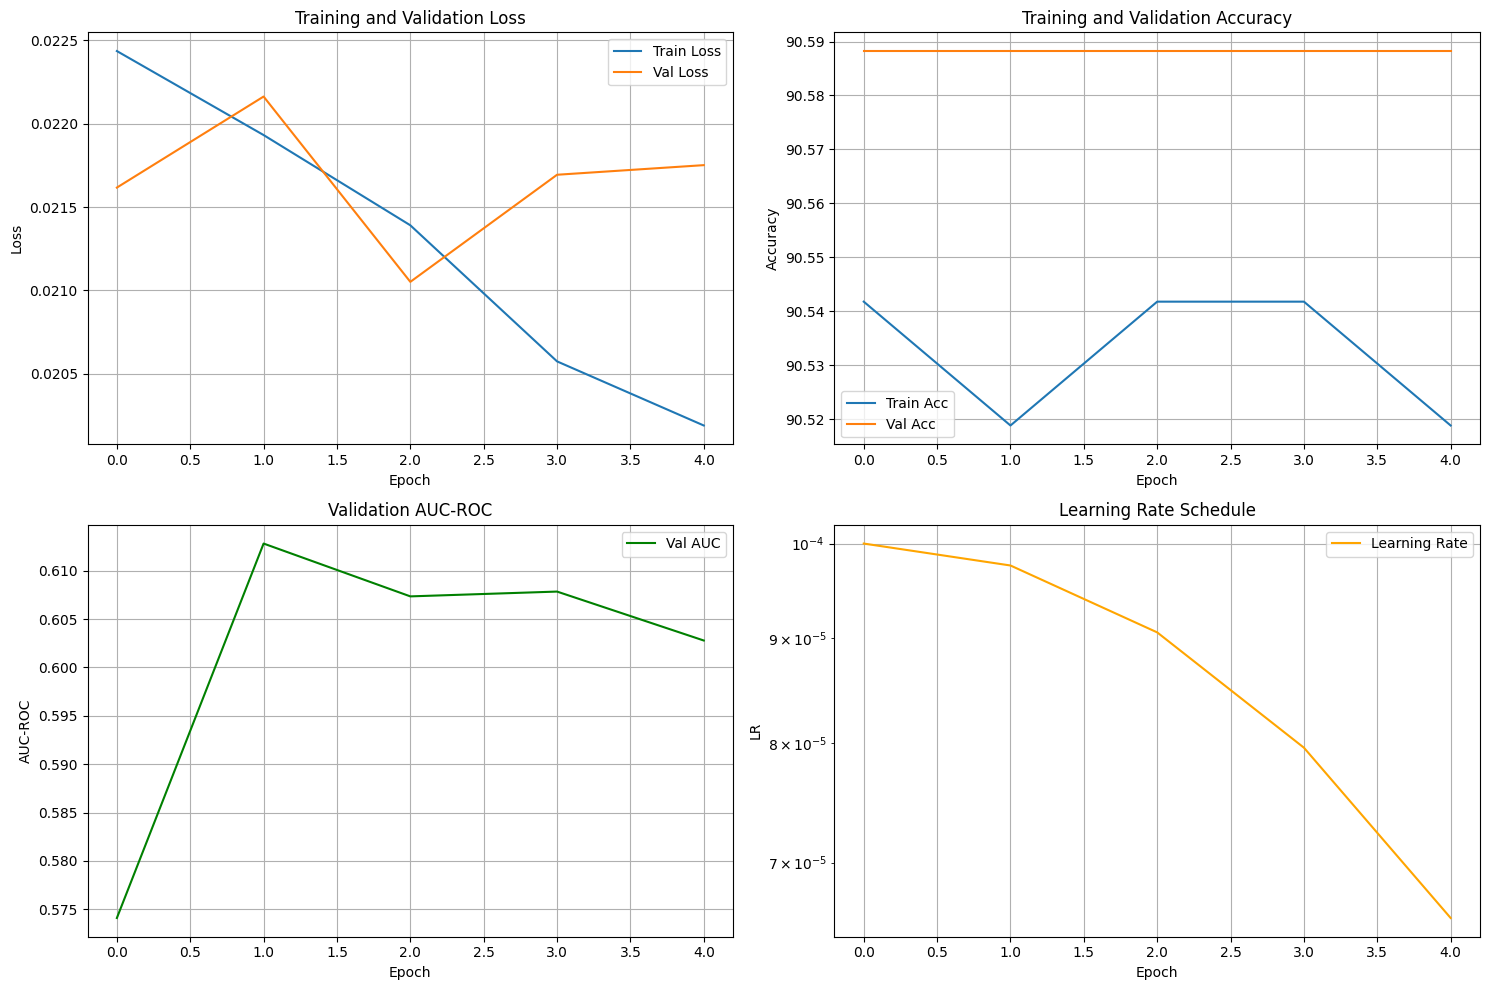

In [18]:
# Phase 1: Train with frozen backbone (first few epochs)
print("\n" + "="*60)
print("PHASE 1: Training with frozen backbone")
print("="*60)

model, metric_tracker = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=5,  # Train for 5 epochs with frozen backbone
    device=device,
    save_dir=Config.MODEL_SAVE_DIR,
    early_stopping=None
)


PHASE 2: Fine-tuning with unfrozen backbone
Backbone unfrozen

Epoch 1/25


Epoch 1 [Val]: 100%|██████████| 234/234 [01:54<00:00,  2.04it/s, loss=0.022, acc=90.6] 



Epoch 1 Summary:
  Train Loss: 0.0198 | Train Acc: 90.54%
  Val Loss: 0.0220 | Val Acc: 90.59% | Val AUC: 0.6018
  Learning Rate: 0.000010
Checkpoint saved: ./models/best_model.pth
  ✓ New best model saved (AUC: 0.6018)

Epoch 2/25


Epoch 2 [Val]: 100%|██████████| 234/234 [02:00<00:00,  1.94it/s, loss=0.022, acc=90.6] 



Epoch 2 Summary:
  Train Loss: 0.0194 | Train Acc: 90.52%
  Val Loss: 0.0220 | Val Acc: 90.59% | Val AUC: 0.6009
  Learning Rate: 0.000035

Epoch 3/25


...


Epoch 9 Summary:
  Train Loss: 0.0215 | Train Acc: 90.56%
  Val Loss: 0.0251 | Val Acc: 90.59% | Val AUC: 0.5980
  Learning Rate: 0.000095

Epoch 10/25


Epoch 10 [Val]: 100%|██████████| 234/234 [02:14<00:00,  1.74it/s, loss=0.0306, acc=90.6]



Epoch 10 Summary:
  Train Loss: 0.0243 | Train Acc: 90.52%
  Val Loss: 0.0306 | Val Acc: 90.59% | Val AUC: 0.5910
  Learning Rate: 0.000091
Checkpoint saved: ./models/checkpoint_epoch_10.pth

Epoch 11/25


Epoch 11 [Val]: 100%|██████████| 234/234 [01:26<00:00,  2.69it/s, loss=0.0602, acc=90.6]



Epoch 11 Summary:
  Train Loss: 0.0392 | Train Acc: 90.52%
  Val Loss: 0.0602 | Val Acc: 90.59% | Val AUC: 0.5926
  Learning Rate: 0.000086

Early stopping triggered at epoch 11


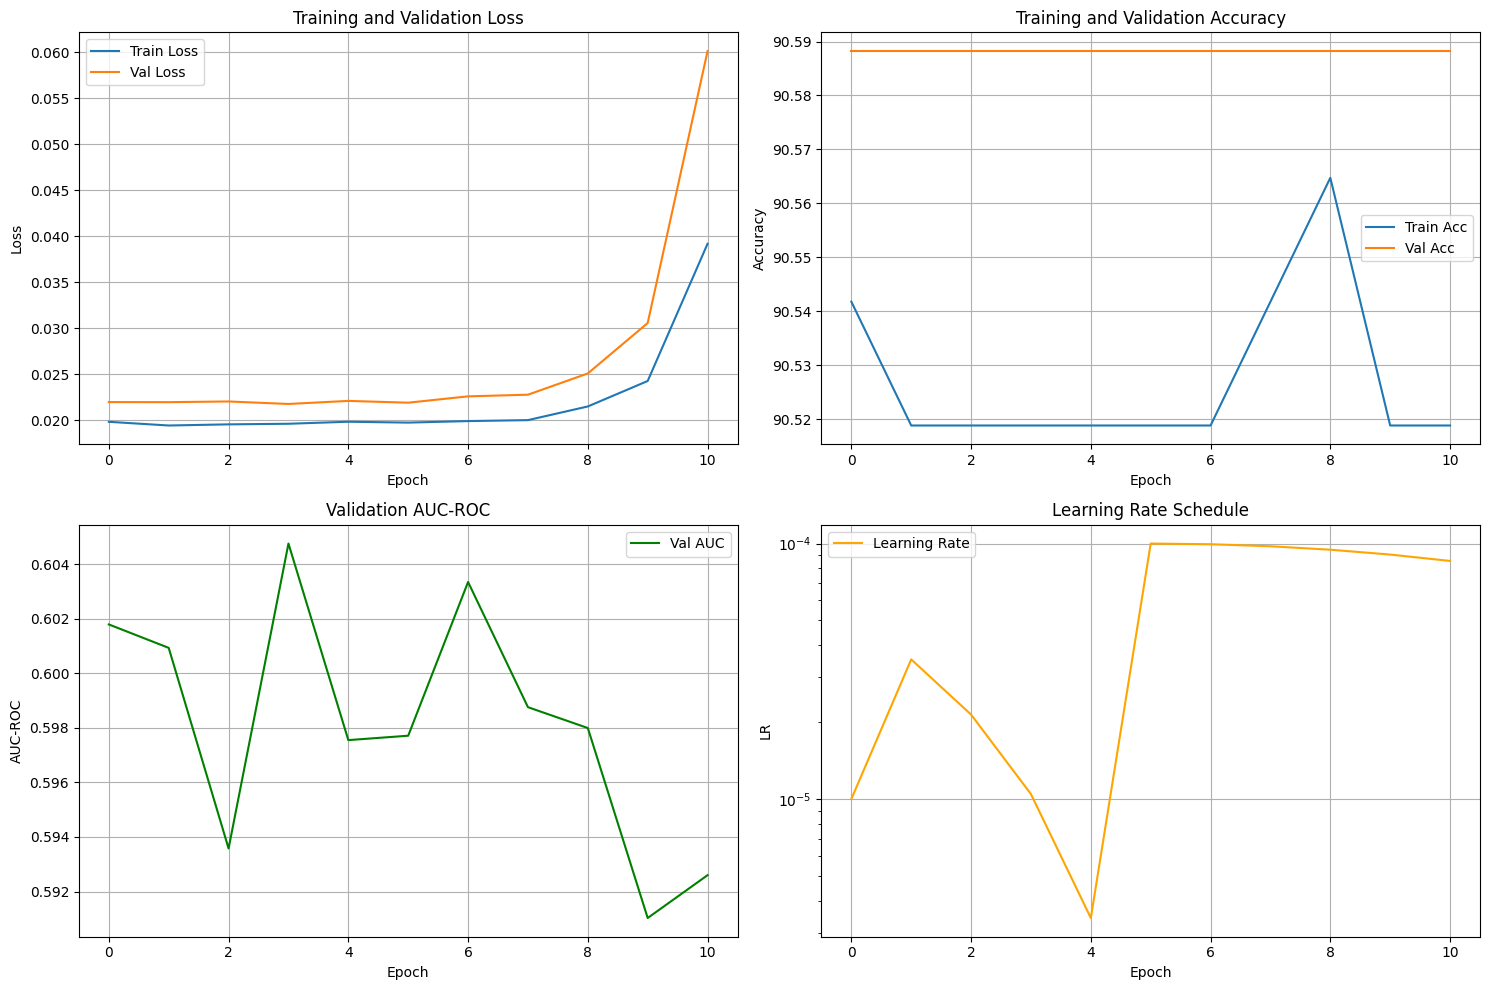

In [19]:
# Phase 2: Unfreeze and fine-tune
print("\n" + "="*60)
print("PHASE 2: Fine-tuning with unfrozen backbone")
print("="*60)

#Changes - Cleared memory using torch
torch.cuda.empty_cache()

# Unfreeze backbone
model.unfreeze_backbone()
print("Backbone unfrozen")

# Lower learning rate for fine-tuning
for param_group in optimizer.param_groups:
    param_group['lr'] = Config.LEARNING_RATE / 10

model, metric_tracker = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=Config.NUM_EPOCHS - 5,  # Remaining epochs
    device=device,
    save_dir=Config.MODEL_SAVE_DIR,
    early_stopping=early_stopping
)

## 11. Final Evaluation on Test Set

Loading best model for final evaluation...

FINAL EVALUATION ON TEST SET
Evaluating model...


100%|██████████| 234/234 [01:31<00:00,  2.56it/s]



Test Results:
  Accuracy: 90.48%
  AUC-ROC: 0.6150

Classification Report:
              precision    recall  f1-score   support

        Real     0.0000    0.0000    0.0000        89
        Fake     0.9048    1.0000    0.9500       846

    accuracy                         0.9048       935
   macro avg     0.4524    0.5000    0.4750       935
weighted avg     0.8187    0.9048    0.8596       935



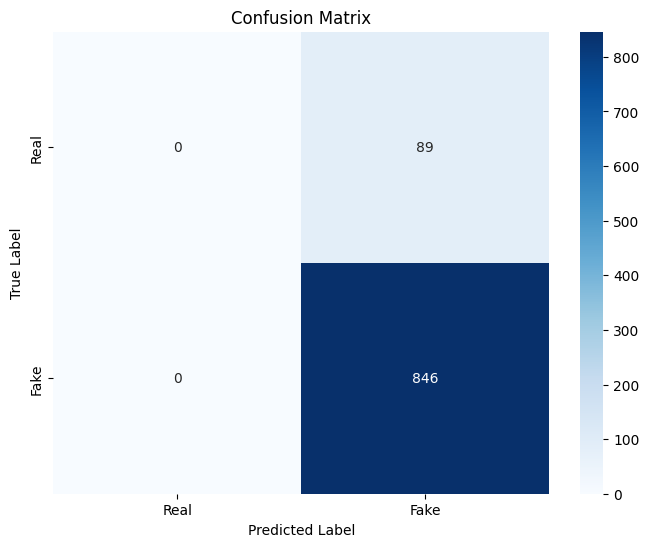

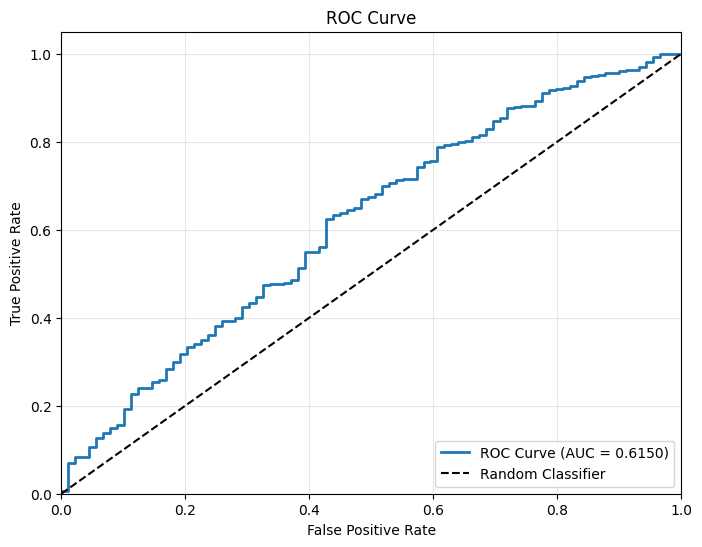


Results saved to ./outputs/test_results.json


In [20]:
# Load best model
print("Loading best model for final evaluation...")
best_model_path = os.path.join(Config.MODEL_SAVE_DIR, 'best_model.pth')
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

test_results = evaluate_model(model, test_loader, device)

# Save results
results_path = os.path.join(Config.OUTPUT_DIR, 'test_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'accuracy': float(test_results['accuracy']),
        'auc': float(test_results['auc'])
    }, f, indent=4)

print(f"\nResults saved to {results_path}")

## 12. Inference on Single Video

In [31]:
def predict_video(model, video_path, face_extractor, device, threshold=0.5):
    """Predict if a video is real or fake"""
    model.eval()
    
    # Extract frames
    frames = extract_frames_from_video(
        video_path,
        num_frames=Config.SEQUENCE_LENGTH,
        face_extractor=face_extractor
    )
    
    # Apply validation transform
    transform = get_validation_augmentation()
    transformed_frames = []
    for frame in frames:
        if frame.dtype != np.uint8:
            frame = (frame * 255).astype(np.uint8) if frame.max() <= 1.0 else frame.astype(np.uint8)
        augmented = transform(image=frame)
        transformed_frames.append(augmented['image'])
    
    frames_tensor = torch.stack(transformed_frames).unsqueeze(0).to(device)  # Add batch dimension
    
    # Predict
    with torch.no_grad():
        output = model(frames_tensor)
        probability = torch.sigmoid(output).item()
        prediction = "FAKE" if probability > threshold else "REAL"
    
    return {
        'prediction': prediction,
        'probability': probability,
        'confidence': probability if probability > 0.5 else 1 - probability
    }


# Example usage
video_path = '/home/andy/Downloads/DF Training BE Proj/datasets/FaceForensics++/faceforeinsics_df/FaceForensics++_C23/original/036.mp4'
result = predict_video(model, video_path, face_extractor, device)
print(f"\nPrediction: {result['prediction']}")
print(f"Probability (fake): {result['probability']:.4f}")
print(f"Confidence: {result['confidence']:.4f}")


Prediction: FAKE
Probability (fake): 0.7341
Confidence: 0.7341


## 13. Save Final Model for Deployment

In [21]:
# Save model for inference
final_model_path = os.path.join(Config.MODEL_SAVE_DIR, 'deepfake_detector_final.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'backbone': Config.BACKBONE,
        'lstm_hidden_size': Config.LSTM_HIDDEN_SIZE,
        'lstm_layers': Config.LSTM_LAYERS,
        'sequence_length': Config.SEQUENCE_LENGTH,
        'frame_size': Config.FRAME_SIZE,
    }
}, final_model_path)

print(f"Final model saved to: {final_model_path}")
print(f"\nModel size: {os.path.getsize(final_model_path) / (1024**2):.2f} MB")

Final model saved to: ./models/deepfake_detector_final.pth

Model size: 34.49 MB


### What We Built:
1. **Multi-dataset deepfake detection** system using CelebDF-v2, FaceForensics++, and DFDC
2. **EfficientNet-B0 + LSTM** architecture with attention mechanism
3. **Advanced augmentation** pipeline for better generalization
4. **GPU-optimized training** with mixed precision (AMP)
5. **Two-phase training**: frozen backbone → fine-tuning
